<a href="https://colab.research.google.com/github/sabriddinovna/graph_nn/blob/main/recap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
x=np.array([[1, 2], [3,4]])
y=np.array([[11, 22], [13,24]])

a color image is a 3d array of shape (h, w, 3)=>(height, weight, rgb channels). batch of images is a 4d array of shape (n, h, w, 3) => (number of images in the batch, height, wieght, rgb channels).  

In [ ]:
images=np.random.default_rng(42).integers(0, 256, size=(16, 32,32,3), dtype=np.uint8)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

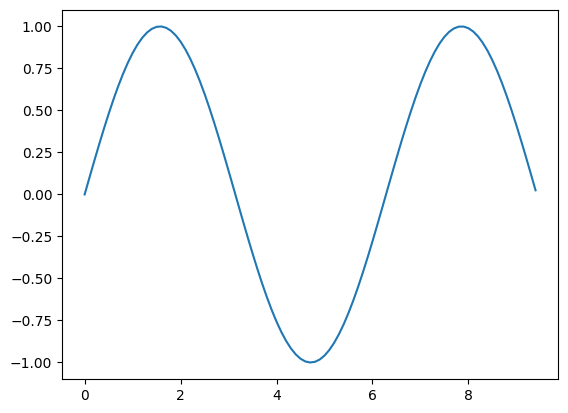

In [ ]:
x=np.arange(0, 3*np.pi, 0.1)
y=np.sin(x)

plt.plot(x,y)

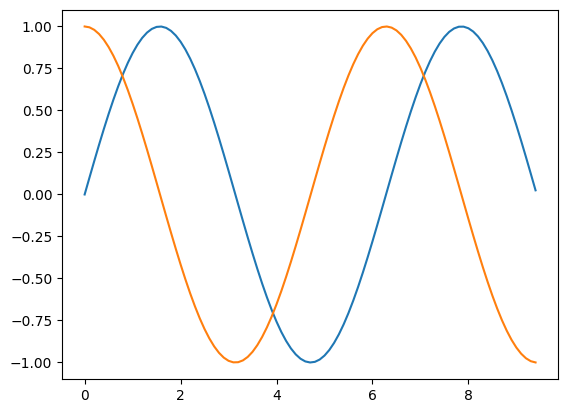

In [ ]:
y_sin=np.sin(x)
y_cos=np.cos(x)
plt.plot(x, y_sin)
plt.plot(x, y_cos)

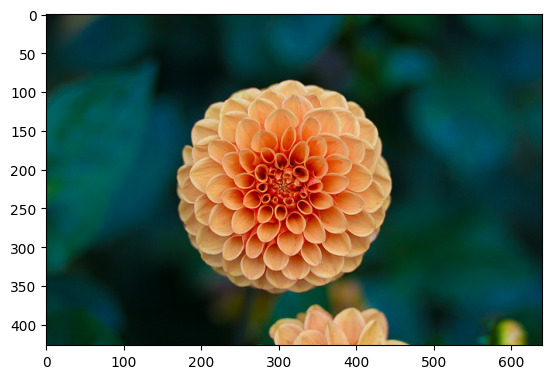

In [ ]:
from sklearn.datasets import load_sample_image

img_arr=load_sample_image('flower.jpg')

plt.imshow(img_arr)

In [ ]:
channel_names=['red','blue','green']


To load the CIFAR-10 dataset with PyTorch, you'll typically use `torchvision.datasets.CIFAR10`. We also need to define transformations for the images.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Define a transformation to convert images to tensors
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) # Normalize to [-1, 1]

# Load the training dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=10)

# Load the test dataset
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=10)

# Example: get one batch of images and labels
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(f"Shape of one batch of images: {images.shape}")
print(f"Shape of one batch of labels: {labels.shape}")

100%|██████████| 170M/170M [35:27<00:00, 80.1kB/s]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rat

Shape of one batch of images: torch.Size([64, 3, 32, 32])
Shape of one batch of labels: torch.Size([64])


In [ ]:
print(len(trainset))

50000


In [ ]:
trainset[0]

(tensor([[[-0.5373, -0.6627, -0.6078,  ...,  0.2392,  0.1922,  0.1608],
          [-0.8745, -1.0000, -0.8588,  ..., -0.0353, -0.0667, -0.0431],
          [-0.8039, -0.8745, -0.6157,  ..., -0.0745, -0.0588, -0.1451],
          ...,
          [ 0.6314,  0.5765,  0.5529,  ...,  0.2549, -0.5608, -0.5843],
          [ 0.4118,  0.3569,  0.4588,  ...,  0.4431, -0.2392, -0.3490],
          [ 0.3882,  0.3176,  0.4039,  ...,  0.6941,  0.1843, -0.0353]],
 
         [[-0.5137, -0.6392, -0.6235,  ...,  0.0353, -0.0196, -0.0275],
          [-0.8431, -1.0000, -0.9373,  ..., -0.3098, -0.3490, -0.3176],
          [-0.8118, -0.9451, -0.7882,  ..., -0.3412, -0.3412, -0.4275],
          ...,
          [ 0.3333,  0.2000,  0.2627,  ...,  0.0431, -0.7569, -0.7333],
          [ 0.0902, -0.0353,  0.1294,  ...,  0.1608, -0.5137, -0.5843],
          [ 0.1294,  0.0118,  0.1137,  ...,  0.4431, -0.0745, -0.2784]],
 
         [[-0.5059, -0.6471, -0.6627,  ..., -0.1529, -0.2000, -0.1922],
          [-0.8431, -1.0000,

### Step 1: Prepare the Data for k-NN

The CIFAR-10 images are 32x32 pixels with 3 color channels (RGB). For k-NN, we typically flatten these images into a 1D feature vector. Since k-NN from scikit-learn works best with NumPy arrays, we'll convert the PyTorch tensors to NumPy arrays and flatten them.

In [ ]:
x_train=np.array([trainset[i][0].numpy() for i in  range(len(trainset))])
x_train=x_train.reshape(len(trainset), -1)

y_train=np.array([trainset[i][1] for i in range(len(trainset))])

NameError: name 'trainset' is not defined

In [ ]:
import numpy as np

# Extract images and labels from the datasets
# For k-NN, we will use the raw tensors before normalization if we want to avoid negative values, or use the normalized ones.
# Let's use the normalized tensors as they are already processed.

# Get all training data and flatten images
X_train = np.array([trainset[i][0].numpy() for i in range(len(trainset))])
X_train = X_train.reshape(len(trainset), -1) # Flatten images: (N, 3, 32, 32) -> (N, 3*32*32)
y_train = np.array([trainset[i][1] for i in range(len(trainset))])

# Get all test data and flatten images
X_test = np.array([testset[i][0].numpy() for i in range(len(testset))])
X_test = X_test.reshape(len(testset), -1) # Flatten images: (N, 3, 32, 32) -> (N, 3*32*32)
y_test = np.array([testset[i][1] for i in range(len(testset))])

print(f"Shape of flattened X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of flattened X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

### Step 2: Implement the k-NN Classifier

We will use `KNeighborsClassifier` from `sklearn.neighbors` to implement the k-NN algorithm. We need to choose a value for `k` (the number of neighbors). For simplicity, let's start with `k=5`.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import time

# Initialize the k-NN classifier
k = 5 # You can experiment with different values of k
knn_classifier = KNeighborsClassifier(n_neighbors=k, n_jobs=-1) # n_jobs=-1 uses all available CPU cores

print(f"Training k-NN classifier with k={k}...")
start_time = time.time()
knn_classifier.fit(X_train, y_train)
end_time = time.time()
print(f"Training complete in {end_time - start_time:.2f} seconds.")

### Step 3: Evaluate the k-NN Classifier

Now, let's make predictions on the test set and calculate the accuracy of our k-NN classifier.

In [ ]:
from sklearn.metrics import accuracy_score

print("Making predictions on the test set...")
start_time = time.time()
y_pred = knn_classifier.predict(X_test)
end_time = time.time()
print(f"Prediction complete in {end_time - start_time:.2f} seconds.")

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of k-NN classifier on the test set (k={k}): {accuracy:.4f}")

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

In [ ]:
#downloading open datasets
training_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),)



100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.21MB/s]


In [ ]:
#download test data from open datasets

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(),v2.ToDtype(torch.float32, scale=True)]),
)

In [ ]:
batch_size=64
train_dataloader=DataLoader(training_data, batch_size=batch_size)

test_dataloader=DataLoader(test_data, batch_size=batch_size)

for x,y in test_dataloader:
  print(x.shape)
  print(y.shape)
  break


torch.Size([64, 1, 28, 28])
torch.Size([64])


In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")


Using cuda device


In [ ]:
class Neuralnetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten= nn.Flatten()
    self.linear_relu_stack=nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512,10)

    )
  def forward(self, x):
    x=self.flatten(x)
    logits=self.linear_relu_stack(x)
    return logits

model= Neuralnetwork().to(device)
print(model)

Neuralnetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),  lr=1e-3)

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
  size=len(dataloader.dataset)
  model.train()
  for batch, (x,y) in enumerate(dataloader):
    x,y=x.to(device), y.to(device)

    pred=model(x)
    loss=loss_fn(pred,y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch % 100==0:
      loss, current = loss.item(), (batch+1)*len(x)
      print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [ ]:
def test(dataloader, model, loss_fn):
  size=len(dataloader.dataset)
  num_batches=len(dataloader)
  model.eval()
  test_loss, correct =0,0
  with torch.no_grad():
    for x, y in dataloader:
      x,y=x.to(device), y.to(device)
      pred=model(x)
      test_loss=loss_fn(pred,y).item()+test_loss
      correct+= (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss/=num_batches
  correct/=size
  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")






In [ ]:
epochs=5
for t in range(epochs):
  print(t)
  train(train_dataloader,  model, loss_fn, optimizer)
  test(test_dataloader, model ,loss_fn)


0
loss: 2.312229  [   64/60000]
loss: 2.294929  [ 6464/60000]
loss: 2.279350  [12864/60000]
loss: 2.268651  [19264/60000]
loss: 2.255507  [25664/60000]
loss: 2.242778  [32064/60000]
loss: 2.234797  [38464/60000]
loss: 2.209768  [44864/60000]
loss: 2.214780  [51264/60000]
loss: 2.183934  [57664/60000]
Test Error: 
 Accuracy: 48.2%, Avg loss: 2.174595 

1
loss: 2.189303  [   64/60000]
loss: 2.172870  [ 6464/60000]
loss: 2.123948  [12864/60000]
loss: 2.133494  [19264/60000]
loss: 2.088314  [25664/60000]
loss: 2.045008  [32064/60000]
loss: 2.061384  [38464/60000]
loss: 1.992322  [44864/60000]
loss: 2.005558  [51264/60000]
loss: 1.935577  [57664/60000]
Test Error: 
 Accuracy: 58.1%, Avg loss: 1.927728 

2
loss: 1.961822  [   64/60000]
loss: 1.925805  [ 6464/60000]
loss: 1.820933  [12864/60000]
loss: 1.854124  [19264/60000]
loss: 1.744593  [25664/60000]
loss: 1.703277  [32064/60000]
loss: 1.719261  [38464/60000]
loss: 1.621585  [44864/60000]
loss: 1.648277  [51264/60000]
loss: 1.539038  [576

In [ ]:

torch.save(model.state_dict(), "model.pth")

In [ ]:
model=Neuralnetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

In [ ]:
classes=[
    "T-shirt",
    "trousers","pullover",
    "dress",
    "coat",
    "sandal",
    "shirt",
    "sneaker",
    "bag",
    "ankle boot",
]

model.eval()
x,y=test_data[2][0], test_data[2][1]
with torch.no_grad():
    x=x.to(device)
    pred=model(x)
    predicted, actual=classes[pred[0].argmax(0)],classes[y]
    print(f'predicted: "{predicted}", actual: "{actual}"')


predicted: "trousers", actual: "trousers"


In [ ]:
import torch
import numpy as np

In [ ]:
data=[[1,2],[3,4]]
x_data=torch.tensor(data)

In [ ]:
x_data

tensor([[1, 2],
        [3, 4]])

In [ ]:
np_arr=np.array(data)
x_np=torch.from_numpy(np_arr)

In [ ]:
x_np

tensor([[1, 2],
        [3, 4]])

In [ ]:
x_ones=torch.ones_like(x_data)
x_ones

tensor([[1, 1],
        [1, 1]])

In [ ]:
x_rand=torch.rand_like(x_np, dtype=torch.float)
x_rand


tensor([[0.7272, 0.1628],
        [0.6475, 0.7566]])

In [ ]:
shape=(2,3)
rand_tensor=torch.rand(shape)
rand_tensor

tensor([[0.2150, 0.4485, 0.6381],
        [0.7458, 0.4042, 0.7839]])

In [ ]:
one_tensor=torch.ones(shape)
one_tensor

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [ ]:
zero_tensor=torch.zeros(shape)
zero_tensor

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [ ]:
#creating custom dataset
import os
import pandas as pd
from torchvision.io import decode_image
from torch.utils.data import Dataset
from torchvision import datasets

In [ ]:
class CustomImgdataset(Dataset):
  def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
    self.img_labels=pd.read_csv(annotations_file)
    self.img_dir=img_dir
    self.transform=transform
    self.target_transform=target_transform

  def __len__(self):
    return len(self.img_labels)

  def __getitem__(self, idx):
    img_path=os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
    image=decode_image(img_path)
    label=self.image_labels.iloc[idx,1]
    if self.transform:
      image=self.transform(image)
    if self.target_transform:
      label=self.target_transform(label)
    return image, label


In [ ]:
from torch.utils.data import DataLoader
train_loader=DataLoader(training_data, batch_size=64, shuffle=True)
test_loader=DataLoader(test_data, batch_size=64, shuffle=True)

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import v2

In [ ]:
ds= datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    target_transform=v2.Lambda(
        lambda y: F.one_hot(torch.tensor(y), num_classes=10).float()
    ),

)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.8MB/s]


In [ ]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
class NN(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten=nn.Flatten()
    self.linear_relu_stack=nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10),)
  def forward(self, x):
    x=self.flatten(x)
    logits=self.linear_relu_stack(x)
    return logits

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
model=NN().to(device)
print(model)

NN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
input_image=torch.rand(3,28,28)
print(input_image.size())

torch.Size([3, 28, 28])


In [ ]:
flatten=nn.Flatten()
flat_img=flatten(input_image)
print(flat_img.size())

torch.Size([3, 784])


In [ ]:
layer1=nn.Linear(in_features=28*28, out_features=20)
hidden1=layer1(flat_img)
print(hidden1.size())


torch.Size([3, 20])


In [ ]:
print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

Before ReLU: tensor([[-0.6980,  0.0597,  0.1741, -0.0226,  0.0514,  0.5346,  0.2371,  0.2473,
          0.4726,  0.2344, -0.3743,  0.3459, -0.1264, -0.0843, -0.1570,  0.5865,
         -0.0191, -0.3123,  0.0049,  0.3426],
        [-0.1815, -0.3293,  0.2676, -0.1129,  0.1131,  0.2537,  0.4417,  0.2363,
          0.6940,  0.1768, -0.0690,  0.1039,  0.0090, -0.0091,  0.0873,  0.2781,
         -0.0873, -0.2621, -0.1362,  0.0580],
        [-0.3646, -0.1867,  0.2276, -0.0101, -0.0284,  0.0313,  0.1117,  0.3878,
          0.6670,  0.2409, -0.0256,  0.5045, -0.1786,  0.0300, -0.2221,  0.5329,
         -0.1050, -0.2237,  0.0938,  0.2145]], grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.0000, 0.0597, 0.1741, 0.0000, 0.0514, 0.5346, 0.2371, 0.2473, 0.4726,
         0.2344, 0.0000, 0.3459, 0.0000, 0.0000, 0.0000, 0.5865, 0.0000, 0.0000,
         0.0049, 0.3426],
        [0.0000, 0.0000, 0.2676, 0.0000, 0.1131, 0.2537, 0.4417, 0.2363, 0.6940,
         0.1768, 0.0000, 0.1039, 0.0090, 0.0000, 0.08

In [ ]:
seq=nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)

inp=torch.rand(3,28,28)
logits=seq(inp)

In [ ]:
print(logits)

tensor([[ 0.0735,  0.2973,  0.2074, -0.3650, -0.2082,  0.0330,  0.1862,  0.2088,
         -0.1100, -0.3378],
        [ 0.1305,  0.1852,  0.1201, -0.1577, -0.0640,  0.0424,  0.2938,  0.2059,
         -0.0408, -0.3235],
        [ 0.0731,  0.0756,  0.1100, -0.2602, -0.0929,  0.0517,  0.2750,  0.2742,
         -0.0643, -0.3376]], grad_fn=<AddmmBackward0>)


In [ ]:
softmax=nn.Softmax(dim=1)
pred_prob=softmax(logits)

In [ ]:
print(pred_prob)

tensor([[0.1051, 0.1315, 0.1202, 0.0678, 0.0793, 0.1009, 0.1177, 0.1204, 0.0875,
         0.0697],
        [0.1079, 0.1140, 0.1068, 0.0809, 0.0888, 0.0988, 0.1270, 0.1163, 0.0909,
         0.0685],
        [0.1046, 0.1048, 0.1085, 0.0749, 0.0886, 0.1024, 0.1280, 0.1278, 0.0911,
         0.0693]], grad_fn=<SoftmaxBackward0>)


In [ ]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[-1.0876e-03,  4.7298e-03,  6.4749e-03,  ..., -3.2306e-03,
          3.3046e-02, -3.3969e-02],
        [ 3.5301e-02, -1.1457e-02, -1.6485e-02,  ..., -4.4659e-03,
         -7.0099e-05,  2.7594e-02]], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([0.0208, 0.0138], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[ 0.0381,  0.0075, -0.0431,  ..., -0.0219, -0.0308,  0.0059],
        [ 0.0305,  0.0011,  0.0204,  ...,  0.0055, -0.0438, 

In [ ]:
import torch
x=torch.ones(5)

In [ ]:
x

tensor([1., 1., 1., 1., 1.])

In [ ]:
y=torch.zeros(3)
w=torch.randn(5,3,requires_grad=True)
b=torch.randn(3, requires_grad=True)
z=torch.matmul(x,w)+b
loss=torch.nn.functional.binary_cross_entropy_with_logits(z, y)


In [ ]:
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.0427, 0.3258, 0.3078],
        [0.0427, 0.3258, 0.3078],
        [0.0427, 0.3258, 0.3078],
        [0.0427, 0.3258, 0.3078],
        [0.0427, 0.3258, 0.3078]])
tensor([0.0427, 0.3258, 0.3078])


In [ ]:
with torch.no_grad():
  z=torch.matmul(x,w)+b
print(z.requires_grad)

False


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

In [ ]:
training_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32,  scale=True)])

    )

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(),v2.ToDtype(torch.float32, scale=True)])

)

train_loader=DataLoader(training_data, batch_size=100)
test_loader=DataLoader(test_data,batch_size=100)


In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

In [ ]:
learning_rate = 1e-3
batch_size = 100

In [ ]:
loss_fn=nn.CrossEntropyLoss()

In [ ]:
opt=torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
def train_loop(dataloader, model, loss_fn, opt):
  size=len(dataloader.dataset)
  model.train()
  for batch,  (X, y) in enumerate(dataloader):
    pred=model(X)
    loss=loss_fn(pred,y)

    loss.backward()
    opt.step()
    opt.zero_grad()

    if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model,  loss_fn):
  model.eval()
  size=len(dataloader.dataset)
  num_batches=len(dataloader)
  test_loss, correct=0,0

  with torch.no_grad():
    for X, y in dataloader:
      pred=model(X)
      test_loss=test_loss+loss_fn(pred,y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss/=num_batches
  correct/=size
  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")



In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, model, loss_fn, optimizer)
    test_loop(test_loader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 1.621948  [  100/60000]
loss: 1.602783  [10100/60000]
loss: 1.599668  [20100/60000]
loss: 1.468514  [30100/60000]
loss: 1.468996  [40100/60000]
loss: 1.440759  [50100/60000]
Test Error: 
 Accuracy: 62.1%, Avg loss: 1.427243 

Epoch 2
-------------------------------
loss: 1.411283  [  100/60000]
loss: 1.389256  [10100/60000]
loss: 1.411667  [20100/60000]
loss: 1.268600  [30100/60000]
loss: 1.274237  [40100/60000]
loss: 1.277725  [50100/60000]
Test Error: 
 Accuracy: 63.5%, Avg loss: 1.268523 

Epoch 3
-------------------------------
loss: 1.253294  [  100/60000]
loss: 1.228373  [10100/60000]
loss: 1.270679  [20100/60000]
loss: 1.124448  [30100/60000]
loss: 1.127332  [40100/60000]
loss: 1.157787  [50100/60000]
Test Error: 
 Accuracy: 64.1%, Avg loss: 1.151574 

Epoch 4
-------------------------------
loss: 1.133664  [  100/60000]
loss: 1.107454  [10100/60000]
loss: 1.166985  [20100/60000]
loss: 1.018250  [30100/60000]
loss: 1.016837  [40100/6

In [ ]:
import torch
import torchvision.models as models

In [ ]:
model=models.vgg16(weights='IMAGENET1K_V1')
torch.save(model.state_dict(), 'model_weights.pth')

if i want to load weights, first model structure shoiuld be saved as class.

In [ ]:
torch.save(model, 'model.pth')

In [ ]:
model=torch.load('model.pth', weights_only=False)